In [1]:
import arcgis
import fastai
import torch

In [2]:
%env CUDA_VISIBLE_DEVICES=0

env: CUDA_VISIBLE_DEVICES=0


In [3]:
from arcgis.learn import prepare_data, SingleShotDetector
from fastai.vision.data import ImageDataBunch

In [4]:
rgb_path = r'/mnt/Raster/Data/Tests_Data/object_detection/data2'

In [13]:
data = prepare_data(rgb_path, batch_size=4, class_mapping={'1': 'palm', '2': 'houses'})

In [14]:
data

ImageDataBunch;

Train: LabelList (144 items)
x: ObjectDetectionItemList
Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224)
y: ObjectDetectionCategoryList
ImageBBox (224, 224),ImageBBox (224, 224),ImageBBox (224, 224),ImageBBox (224, 224),ImageBBox (224, 224)
Path: \\ndhfs1\Raster\Data\Tests_Data\object_detection\data2\images;

Valid: LabelList (16 items)
x: ObjectDetectionItemList
Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224)
y: ObjectDetectionCategoryList
ImageBBox (224, 224),ImageBBox (224, 224),ImageBBox (224, 224),ImageBBox (224, 224),ImageBBox (224, 224)
Path: \\ndhfs1\Raster\Data\Tests_Data\object_detection\data2\images;

Test: None

In [15]:
assert isinstance(data, ImageDataBunch)

In [16]:
data.class_mapping

{1: 'palm', 2: 'houses'}

In [17]:
assert isinstance(data.class_mapping, dict)

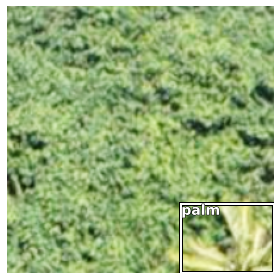

In [22]:
data.show_batch(rows=1)

In [23]:
model = SingleShotDetector(data)

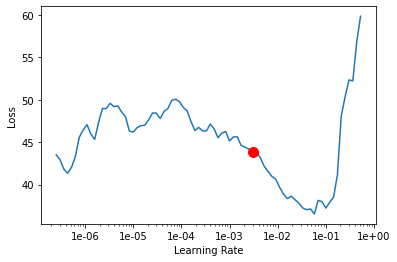

0.0030199517204020187

In [24]:
model.lr_find()

In [25]:
model.fit(10)

epoch,train_loss,valid_loss,time
0,44.092762,20.974325,00:30
1,30.596138,12.475183,00:31
2,20.841688,10.380863,00:32
3,16.534851,10.909414,00:32
4,15.065322,8.664033,00:31
5,13.399803,9.642828,00:31
6,12.805656,8.358150,00:30
7,12.374525,8.460069,00:32
8,12.842166,8.212230,00:31
9,12.403427,7.954653,00:33


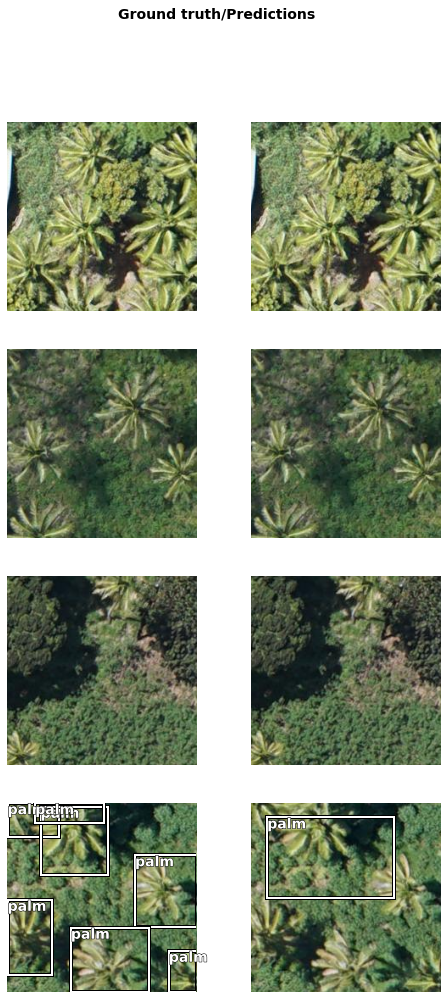

In [26]:
model.show_results()

In [12]:
model.save(r'/home/administrator/Raster/notebook_test_model')

WindowsPath('//ndhfs1/Raster/Data/testdata/extracted_data/object_detection_data/palm-tree-256/models/fastTest')

In [27]:
score = model.average_precision_score()

In [29]:
score

{'houses': 0.0, 'palm': 0.5919089141823592}

In [28]:
score.get('palm')

0.5919089141823592